# Modelos basados en Árboles de Decisión — Predicción de Churn

Este cuaderno entrena y ajusta **tres modelos basados en árboles de decisión** para predecir
`Attrition_Flag` (cancelación de tarjeta de crédito) usando el dataset ya procesado
(`BankChurners_variables_seleccionadas_sin_transformar.csv`, sin nulos y con las variables ya
seleccionadas):

1. **Árbol de Decisión** (`DecisionTreeClassifier`)
2. **Random Forest** (`RandomForestClassifier`)
3. **Gradient Boosting** (`XGBoost` si está disponible en tu entorno; en caso contrario,
   `GradientBoostingClassifier` de scikit-learn como alternativa equivalente)

Cada modelo se ajusta con `GridSearchCV` (validación cruzada) y se evalúa sobre un conjunto de
prueba común. Al final, los tres modelos entrenados se guardan en `.pkl` con el mismo formato
que `modelo_regresion_logistica_churn.pkl`, para poder compararlos todos en el segundo cuaderno
(`02_comparacion_modelos_churn.ipynb`).

> A diferencia de la regresión logística, los árboles de decisión **no necesitan que las
> variables numéricas estén escaladas/estandarizadas**, así que se entrenan directamente sobre
> los valores originales.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve,
)

RANDOM_STATE = 42
DATA_PATH = "data/BankChurners_variables_seleccionadas_sin_transformar.csv"
MODELOS_DIR = "modelos"

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (6, 4)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Carga de datos

El dataset ya viene sin nulos y con las variables relevantes seleccionadas.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.head()

Filas: 10127  |  Columnas: 11


,Customer_Age,Gender,Education_Level,Marital_Status,Income_Category,Card_Category,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio,Attrition_Flag
0,45,M,High School,Married,$60K - $80K,Blue,12691.0,1144,42,0.061,Existing Customer
1,49,F,Graduate,Single,Less than $40K,Blue,8256.0,1291,33,0.105,Existing Customer
2,51,M,Graduate,Married,$80K - $120K,Blue,3418.0,1887,20,0.000,Existing Customer
3,40,F,High School,Unknown,Less than $40K,Blue,3313.0,1171,20,0.760,Existing Customer
4,40,M,Uneducated,Married,$60K - $80K,Blue,4716.0,816,28,0.000,Existing Customer


In [3]:
df["Attrition_Flag"].value_counts(normalize=True).rename("proporción").to_frame()

,proporción
Attrition_Flag,
Existing Customer,0.83934
Attrited Customer,0.16066


## 2. Preparación de variables

- **Variable objetivo:** `Attrition_Flag` se codifica como `1 = Attrited Customer` (cliente que
  cancela, clase positiva) y `0 = Existing Customer`, igual que en el modelo de regresión
  logística ya entrenado (`clase_positiva = 1`).
- **Variables categóricas:** `Gender`, `Education_Level`, `Marital_Status`, `Income_Category`,
  `Card_Category` se codifican con **one-hot encoding** (`pd.get_dummies`), generando las mismas
  28 columnas que usa `modelo_regresion_logistica_churn.pkl`. Esto es clave para poder comparar
  los modelos de forma justa en el segundo cuaderno.

In [4]:
df["Attrition_Flag"] = df["Attrition_Flag"].map({"Existing Customer": 0, "Attrited Customer": 1})

cat_cols = ["Gender", "Education_Level", "Marital_Status", "Income_Category", "Card_Category"]
X = pd.get_dummies(df.drop(columns=["Attrition_Flag"]), columns=cat_cols)
X = X.astype({c: int for c in X.select_dtypes("bool").columns})
y = df["Attrition_Flag"]

print(f"X: {X.shape[0]} filas x {X.shape[1]} columnas")
print(f"Columnas: {list(X.columns)}")

X: 10127 filas x 28 columnas
Columnas: ['Customer_Age', 'Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio', 'Gender_F', 'Gender_M', 'Education_Level_College', 'Education_Level_Doctorate', 'Education_Level_Graduate', 'Education_Level_High School', 'Education_Level_Post-Graduate', 'Education_Level_Uneducated', 'Education_Level_Unknown', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Unknown', 'Income_Category_$120K +', 'Income_Category_$40K - $60K', 'Income_Category_$60K - $80K', 'Income_Category_$80K - $120K', 'Income_Category_Less than $40K', 'Income_Category_Unknown', 'Card_Category_Blue', 'Card_Category_Gold', 'Card_Category_Platinum', 'Card_Category_Silver']


## 3. Partición train/test

Se usa una partición 80/20 estratificada, con `random_state=42` (la misma semilla que reutilizará el cuaderno de comparación).

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Entrenamiento: {X_train.shape[0]} filas  |  Prueba: {X_test.shape[0]} filas")
print(f"Tasa de churn en train: {y_train.mean():.3f}  |  en test: {y_test.mean():.3f}")

Entrenamiento: 8101 filas  |  Prueba: 2026 filas
Tasa de churn en train: 0.161  |  en test: 0.160


## 4. Función auxiliar de evaluación

Se define una función común para evaluar cualquier modelo sobre el conjunto de prueba, y así
usar exactamente las mismas métricas para los tres modelos.

In [6]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    metricas = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
    }

    print(f"===== {nombre} =====")
    print(classification_report(y_test, y_pred, target_names=["Existing (0)", "Attrited (1)"]))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    cm = confusion_matrix(y_test, y_pred)
    axes[0].imshow(cm, cmap="Blues")
    axes[0].set_title(f"Matriz de confusión — {nombre}")
    axes[0].set_xlabel("Predicho")
    axes[0].set_ylabel("Real")
    axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Existing", "Attrited"])
    axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["Existing", "Attrited"])
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, cm[i, j], ha="center", va="center",
                         color="white" if cm[i, j] > cm.max() / 2 else "black")

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f"AUC = {metricas['ROC_AUC']:.3f}")
    axes[1].plot([0, 1], [0, 1], "--", color="gray")
    axes[1].set_xlabel("Tasa de falsos positivos")
    axes[1].set_ylabel("Tasa de verdaderos positivos")
    axes[1].set_title(f"Curva ROC — {nombre}")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    return metricas

resultados = []

## 5. Árbol de Decisión (`DecisionTreeClassifier`)

Se ajustan hiperparámetros con `GridSearchCV` (validación cruzada de 5 folds, optimizando
`roc_auc`) sobre `max_depth`, `min_samples_leaf` y el criterio de partición. Se usa
`class_weight="balanced"` porque las clases están desbalanceadas (~16% churn).

In [7]:
param_grid_dt = {
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"],
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    param_grid_dt, cv=5, scoring="roc_auc", n_jobs=-1,
)
grid_dt.fit(X_train, y_train)

modelo_dt = grid_dt.best_estimator_
print("Mejores hiperparámetros:", grid_dt.best_params_)
print(f"ROC_AUC promedio (CV): {grid_dt.best_score_:.4f}")

Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 20}
ROC_AUC promedio (CV): 0.9501


===== Árbol de Decisión =====
              precision    recall  f1-score   support

Existing (0)       0.98      0.89      0.93      1701
Attrited (1)       0.60      0.91      0.73       325

    accuracy                           0.89      2026
   macro avg       0.79      0.90      0.83      2026
weighted avg       0.92      0.89      0.90      2026



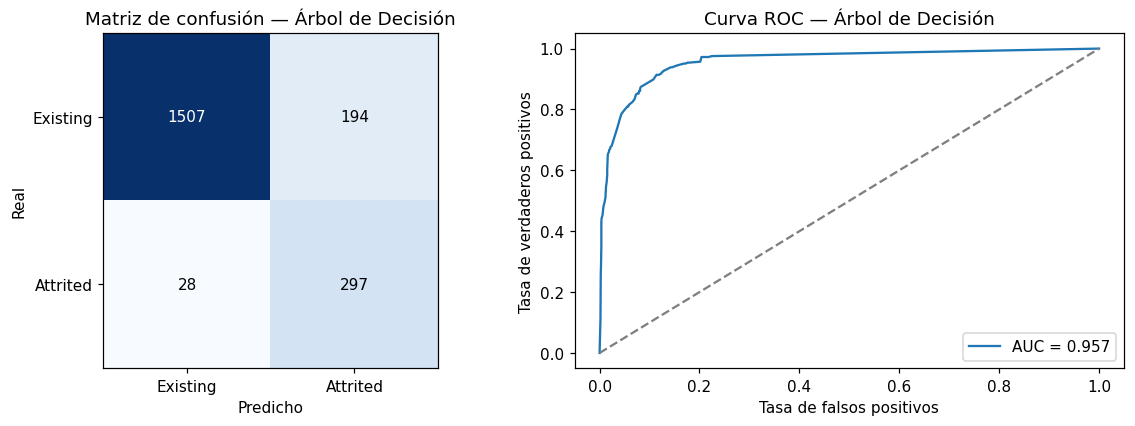

In [8]:
resultados.append(evaluar_modelo("Árbol de Decisión", modelo_dt, X_test, y_test))

### Importancia de variables — Árbol de Decisión

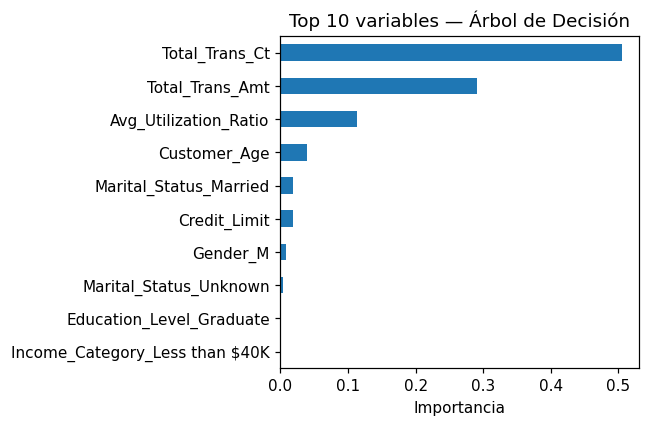

In [9]:
importancias_dt = pd.Series(modelo_dt.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
importancias_dt.plot(kind="barh", figsize=(6, 4), title="Top 10 variables — Árbol de Decisión")
plt.gca().invert_yaxis()
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

## 6. Random Forest (`RandomForestClassifier`)

Se busca el número de árboles, la profundidad máxima y el mínimo de muestras por hoja con
`GridSearchCV`.

In [10]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [8, 12, None],
    "min_samples_leaf": [1, 5],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1),
    param_grid_rf, cv=5, scoring="roc_auc", n_jobs=-1,
)
grid_rf.fit(X_train, y_train)

modelo_rf = grid_rf.best_estimator_
print("Mejores hiperparámetros:", grid_rf.best_params_)
print(f"ROC_AUC promedio (CV): {grid_rf.best_score_:.4f}")

Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
ROC_AUC promedio (CV): 0.9676


===== Random Forest =====
              precision    recall  f1-score   support

Existing (0)       0.93      0.98      0.95      1701
Attrited (1)       0.88      0.59      0.71       325

    accuracy                           0.92      2026
   macro avg       0.90      0.79      0.83      2026
weighted avg       0.92      0.92      0.92      2026



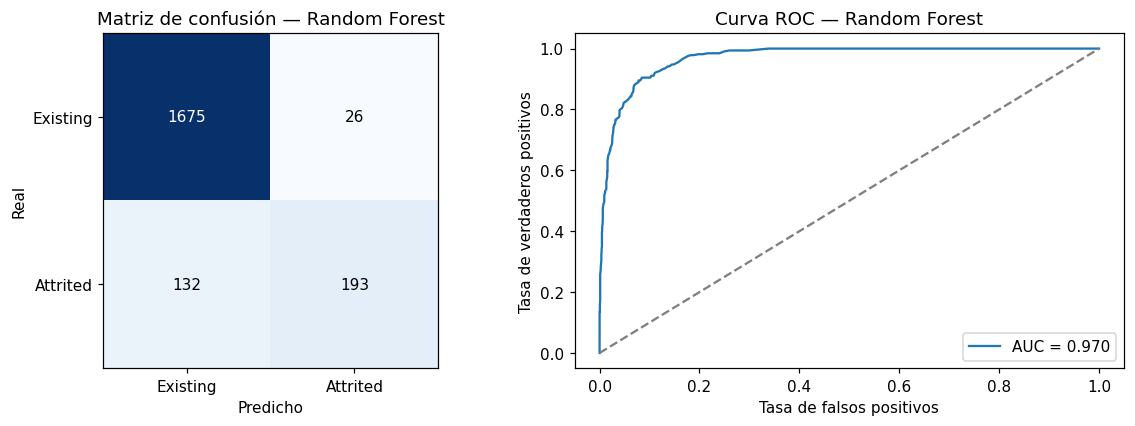

In [11]:
resultados.append(evaluar_modelo("Random Forest", modelo_rf, X_test, y_test))

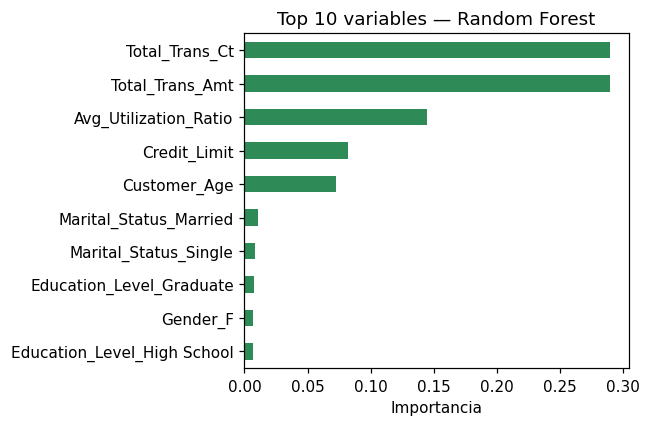

In [12]:
importancias_rf = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
importancias_rf.plot(kind="barh", figsize=(6, 4), title="Top 10 variables — Random Forest", color="seagreen")
plt.gca().invert_yaxis()
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

## 7. Gradient Boosting (XGBoost / GradientBoostingClassifier)

Se intenta usar **XGBoost** (`XGBClassifier`); si el paquete no está instalado en el entorno
donde corras este cuaderno, se usa automáticamente `GradientBoostingClassifier` de
scikit-learn, que sigue el mismo principio de *boosting* de árboles.

In [13]:
try:
    from xgboost import XGBClassifier
    xgb_disponible = True
    boost_base = XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")
    print("Usando XGBoost (XGBClassifier).")
except ImportError:
    xgb_disponible = False
    boost_base = GradientBoostingClassifier(random_state=RANDOM_STATE)
    print("XGBoost no está instalado en este entorno: usando GradientBoostingClassifier de scikit-learn.")

param_grid_boost = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
}

grid_boost = GridSearchCV(boost_base, param_grid_boost, cv=5, scoring="roc_auc", n_jobs=-1)
grid_boost.fit(X_train, y_train)

modelo_boost = grid_boost.best_estimator_
nombre_boost = "XGBoost" if xgb_disponible else "Gradient Boosting"
print("Mejores hiperparámetros:", grid_boost.best_params_)
print(f"ROC_AUC promedio (CV): {grid_boost.best_score_:.4f}")

XGBoost no está instalado en este entorno: usando GradientBoostingClassifier de scikit-learn.
Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
ROC_AUC promedio (CV): 0.9750


===== Gradient Boosting =====
              precision    recall  f1-score   support

Existing (0)       0.95      0.99      0.97      1701
Attrited (1)       0.91      0.74      0.82       325

    accuracy                           0.95      2026
   macro avg       0.93      0.86      0.89      2026
weighted avg       0.94      0.95      0.94      2026



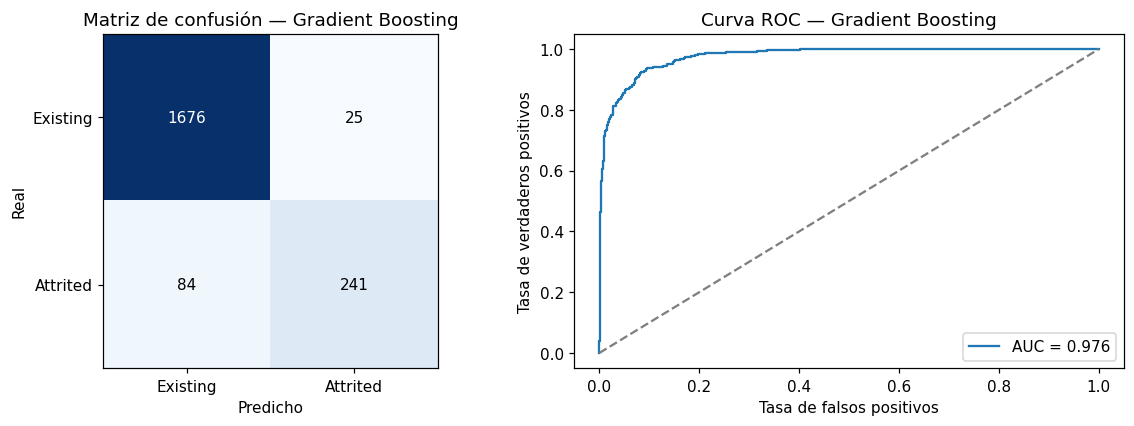

In [14]:
resultados.append(evaluar_modelo(nombre_boost, modelo_boost, X_test, y_test))

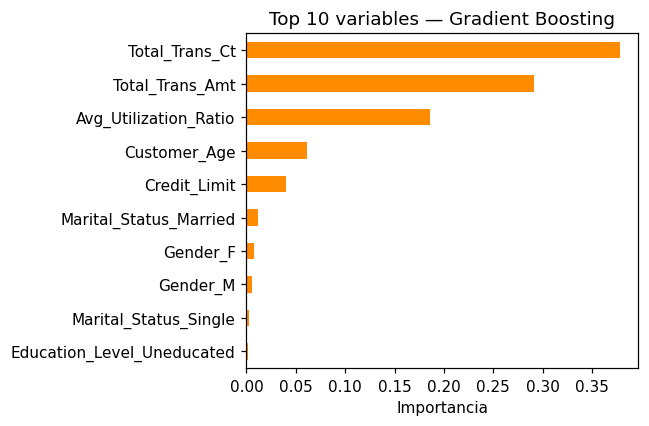

In [15]:
importancias_boost = pd.Series(modelo_boost.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
importancias_boost.plot(kind="barh", figsize=(6, 4), title=f"Top 10 variables — {nombre_boost}", color="darkorange")
plt.gca().invert_yaxis()
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

## 8. Comparación de los tres modelos basados en árboles

In [16]:
tabla_resultados = pd.DataFrame(resultados).set_index("Modelo").sort_values("ROC_AUC", ascending=False)
tabla_resultados.round(4)

,Accuracy,Precision,Recall,F1,ROC_AUC
Modelo,,,,,
Gradient Boosting,0.9462,0.9060,0.7415,0.8156,0.9763
Random Forest,0.9220,0.8813,0.5938,0.7096,0.9700
Árbol de Decisión,0.8904,0.6049,0.9138,0.7279,0.9573


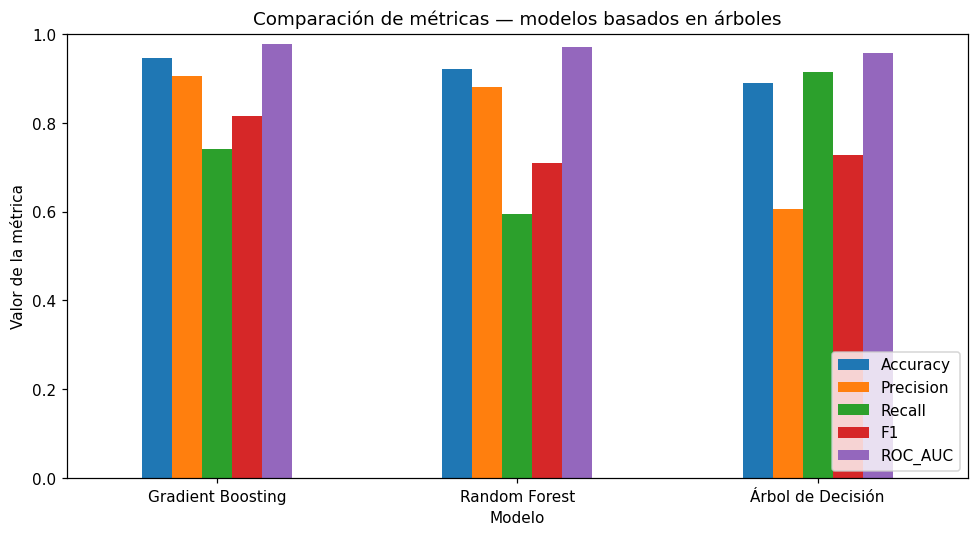

In [17]:
tabla_resultados[["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]].plot(
    kind="bar", figsize=(9, 5), ylim=(0, 1), rot=0,
)
plt.title("Comparación de métricas — modelos basados en árboles")
plt.ylabel("Valor de la métrica")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 9. Guardado de los modelos entrenados

Cada modelo se guarda con la misma estructura de diccionario que
`modelo_regresion_logistica_churn.pkl` (`modelo`, `columnas`, `clase_positiva`, `descripcion`),
para que el cuaderno de comparación (`02_comparacion_modelos_churn.ipynb`) pueda cargarlos de
forma homogénea.

In [18]:
def guardar_modelo(modelo, nombre_archivo, descripcion):
    paquete = {
        "modelo": modelo,
        "columnas": list(X.columns),
        "clase_positiva": 1,
        "descripcion": descripcion,
    }
    ruta = f"{MODELOS_DIR}/{nombre_archivo}"
    joblib.dump(paquete, ruta)
    print(f"Guardado: {ruta}")

guardar_modelo(modelo_dt, "modelo_arbol_decision_churn.pkl",
                "Arbol de Decision - prediccion de cancelacion de tarjeta de credito (Attrition_Flag)")
guardar_modelo(modelo_rf, "modelo_random_forest_churn.pkl",
                "Random Forest - prediccion de cancelacion de tarjeta de credito (Attrition_Flag)")
guardar_modelo(modelo_boost, "modelo_boosting_churn.pkl",
                f"{nombre_boost} - prediccion de cancelacion de tarjeta de credito (Attrition_Flag)")

Guardado: modelos/modelo_arbol_decision_churn.pkl
Guardado: modelos/modelo_random_forest_churn.pkl
Guardado: modelos/modelo_boosting_churn.pkl


## Conclusión de este cuaderno

Los tres modelos quedaron entrenados, ajustados por validación cruzada y evaluados sobre el
mismo conjunto de prueba. Sus archivos `.pkl` están listos en la carpeta `modelos/` junto con
`modelo_regresion_logistica_churn.pkl`. El cuaderno **`02_comparacion_modelos_churn.ipynb`**
carga los cuatro modelos (regresión logística + los tres basados en árboles) y los compara
sobre el mismo conjunto de prueba.